In [ ]:
# Install or import needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
df= pd.read_csv("/content/bankloans.csv")
df.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


In [ ]:
# Features we will use
X = df[['age', 'ed', 'employ', 'address', 'income', 'debtinc', 'creddebt', 'othdebt']]

# Target variable
y = df['default']

# Drop rows with missing values in the target variable
df = df.dropna(subset=['default'])  # Drop rows where 'default' is NaN

# Recreate X and y after dropping NaN values
X = df[['age', 'ed', 'employ', 'address', 'income', 'debtinc', 'creddebt', 'othdebt']]
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Initialize and train the model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
# Predict on test set
y_pred = log_reg.predict(X_test)

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.95      0.90       102
         1.0       0.81      0.58      0.68        38

    accuracy                           0.85       140
   macro avg       0.84      0.76      0.79       140
weighted avg       0.85      0.85      0.84       140

Confusion Matrix:
 [[97  5]
 [16 22]]
Accuracy Score: 0.85


In [ ]:
# Predict probabilities
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# Add probabilities to a DataFrame
results = X_test.copy()
results['Actual_Default'] = y_test
results['Predicted_Probability'] = y_pred_proba

# View top risky customers
results.sort_values('Predicted_Probability', ascending=False).head(10)


,age,ed,employ,address,income,debtinc,creddebt,othdebt,Actual_Default,Predicted_Probability
300,47,1,29,18,129,25.3,20.561310,12.075690,1.0,0.984542
599,28,2,3,4,41,25.1,5.896743,4.394257,1.0,0.961604
65,32,2,11,6,75,23.3,7.758900,9.716100,1.0,0.905537
499,41,2,6,0,36,19.5,4.513860,2.506140,1.0,0.888875
338,28,3,6,8,47,19.8,5.574294,3.731706,1.0,0.833263
570,27,4,0,0,25,12.7,1.419225,1.755775,1.0,0.763627
55,37,1,1,3,24,15.1,1.801128,1.822872,1.0,0.752570
223,29,3,5,6,70,19.9,3.176040,10.753960,1.0,0.748736
549,41,3,12,11,86,26.5,4.991010,17.798990,1.0,0.734054
199,31,2,6,6,32,23.1,3.341184,4.050816,1.0,0.702628


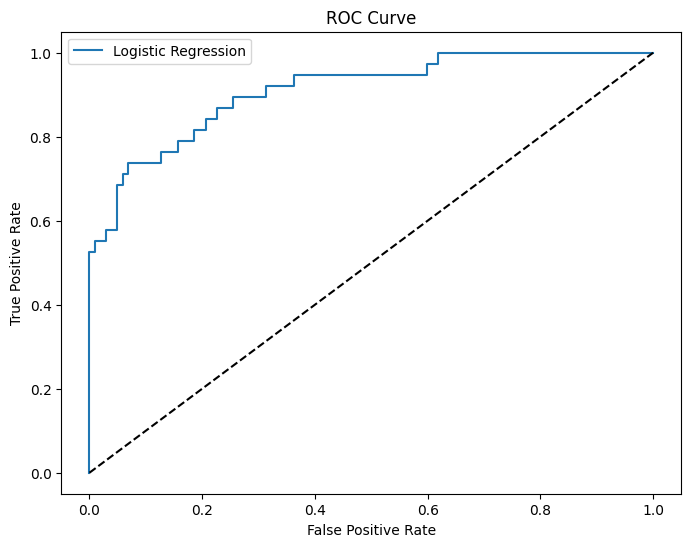

ROC AUC Score: 0.9102167182662539


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print('ROC AUC Score:', roc_auc_score(y_test, y_pred_proba))


In [ ]:
results.to_csv('/content/predicted_defaults.csv', index=False)
